# Handwriting Recognition

In [12]:
## import libraries
from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

In [13]:
print(torch.__version__)

2.12.1


In [14]:
args={}
kwargs={}
args['batch_size']=4
args['test_batch_size']=4
args['epochs']=1  #The number of Epochs is the number of times you go through the full dataset.
args['lr']=0.01 #Learning rate is how fast it will decend.
args['momentum']=0.1 #SGD momentum (default: 0.5) Momentum is a moving average of our gradients (helps to keep direction).
args['seed']=1 #random seed
args['log_interval']=1000
args['cuda']=False #if the computer has a GPU, type True, otherwise, False

In [15]:
## transformations
transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])

## download and load training dataset
trainset = datasets.MNIST(root='../data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=args['batch_size'], shuffle=True, **kwargs)

## download and load testing dataset
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=args['test_batch_size'], shuffle=True, **kwargs)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


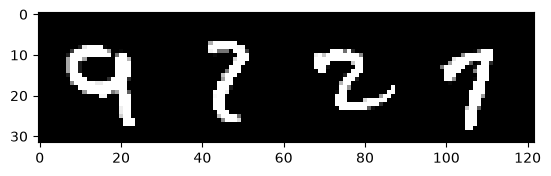

In [16]:
import matplotlib.pyplot as plt
import numpy as np

## functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

## get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

## show images
imshow(torchvision.utils.make_grid(images))

In [17]:
for images, labels in train_loader:
    print("Image batch dimensions:", images.shape)
    print("Image label dimensions:", labels.shape)
    break

Image batch dimensions: torch.Size([4, 1, 28, 28])
Image label dimensions: torch.Size([4])


In [18]:
class Net(nn.Module):
    #This defines the structure of the NN.
    def __init__(self):
        super(Net, self).__init__()
        
        self.conv1 = nn.Conv2d( # convolutional layer 1
            in_channels=1,
            out_channels=32,
            kernel_size=5,
            padding=2
        )

        self.conv2 = nn.Conv2d( # convolutional layer 2
            in_channels=32,
            out_channels=64,
            kernel_size=5,
            padding=2
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # pooling layer

        self.fc1 = nn.Linear(64 * 7 * 7, 256) # fully connected 1, (64 channels, 7x7 image size after pooling)
        self.fc2 = nn.Linear(256, 10) # fully connected 2, (10 classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        x = x.view(x.size(0), -1) # flatten the tensor for the fully connected layer

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        #Softmax gets probabilities.
        return F.log_softmax(x, dim=1)


In [19]:
## test the model with 1 batch
model = Net()
#print(model)
for images, labels in train_loader:
    print("batch size:", args['batch_size'])
    out = model(images)
    print(out.shape)
    break

batch size: 4
torch.Size([4, 10])


In [20]:
def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        if args['cuda']:
            data, target = data.cuda(), target.cuda()
        #Variables in Pytorch are differenciable.
        data, target = Variable(data), Variable(target)
        #This will zero out the gradients for this batch.
        optimizer.zero_grad()
        output = model(data)
        # Calculate the loss The negative log likelihood loss. It is useful to train a classification problem with C classes.
        loss = F.nll_loss(output, target)
        #dloss/dx for every Variable
        loss.backward()
        #to do a one-step update on our parameter.
        optimizer.step()
        #Print out the loss periodically.
        if batch_idx % args['log_interval'] == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.data.item()))

In [21]:
def test():
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
      for data, target in test_loader:
          if args['cuda']:
              data, target = data.cuda(), target.cuda()
          data, target = Variable(data), Variable(target)
          output = model(data)
          test_loss += F.nll_loss(output, target, size_average=False).data.item() # sum up batch loss
          pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
          correct += pred.eq(target.data.view_as(pred)).long().cpu().sum()

    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [22]:
model = Net()
if args['cuda']:
    model.cuda()

optimizer = optim.SGD(model.parameters(), lr=args['lr'], momentum=args['momentum'])

for epoch in range(1, args['epochs'] + 1):
    train(epoch)
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329596
Train Epoch: 1 [4000/60000 (7%)]	Loss: 0.090806
Train Epoch: 1 [8000/60000 (13%)]	Loss: 0.068640
Train Epoch: 1 [12000/60000 (20%)]	Loss: 0.436361
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.082864
Train Epoch: 1 [20000/60000 (33%)]	Loss: 0.278855
Train Epoch: 1 [24000/60000 (40%)]	Loss: 0.002578
Train Epoch: 1 [28000/60000 (47%)]	Loss: 0.020526
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.043365
Train Epoch: 1 [36000/60000 (60%)]	Loss: 0.001022
Train Epoch: 1 [40000/60000 (67%)]	Loss: 0.000042
Train Epoch: 1 [44000/60000 (73%)]	Loss: 0.009932
Train Epoch: 1 [48000/60000 (80%)]	Loss: 0.005650
Train Epoch: 1 [52000/60000 (87%)]	Loss: 0.000922
Train Epoch: 1 [56000/60000 (93%)]	Loss: 0.000174

Test set: Average loss: 0.0379, Accuracy: 9871/10000 (99%)

